## Exercício

Considere $X \sim \mathrm{Binomial}(n,p)$.

1. Implemente a simulação de $X$ pelo método ingênuo, escrevendo $X$ como soma de $n$ variáveis aleatórias independentes com distribuição $\mathrm{Bernoulli}(p)$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# biblioteca para ter a barra de progresso
from tqdm import tqdm

In [3]:
import time

In [4]:
# jeito facil de fazer uma binomial
amostra_binomial = []
n = 1000
p = 0.5
N = 100
for i in range(N):
    uniforme = np.random.uniform(size=n)
    binomial = np.sum(uniforme < p)
    amostra_binomial.append(binomial)

(array([ 5.,  5., 11., 13., 14., 26., 11., 11.,  1.,  3.]),
 array([465. , 472.2, 479.4, 486.6, 493.8, 501. , 508.2, 515.4, 522.6,
        529.8, 537. ]),
 <BarContainer object of 10 artists>)

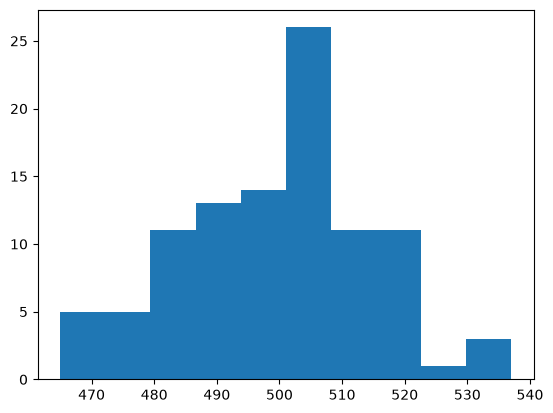

In [5]:
plt.hist(amostra_binomial)

In [6]:
amostra_binomial

[np.int64(507),
 np.int64(515),
 np.int64(475),
 np.int64(511),
 np.int64(485),
 np.int64(479),
 np.int64(505),
 np.int64(499),
 np.int64(483),
 np.int64(511),
 np.int64(507),
 np.int64(504),
 np.int64(499),
 np.int64(510),
 np.int64(530),
 np.int64(527),
 np.int64(493),
 np.int64(518),
 np.int64(476),
 np.int64(504),
 np.int64(520),
 np.int64(491),
 np.int64(506),
 np.int64(500),
 np.int64(508),
 np.int64(522),
 np.int64(514),
 np.int64(486),
 np.int64(486),
 np.int64(480),
 np.int64(484),
 np.int64(503),
 np.int64(508),
 np.int64(515),
 np.int64(520),
 np.int64(508),
 np.int64(502),
 np.int64(482),
 np.int64(518),
 np.int64(515),
 np.int64(483),
 np.int64(483),
 np.int64(493),
 np.int64(521),
 np.int64(487),
 np.int64(508),
 np.int64(479),
 np.int64(518),
 np.int64(488),
 np.int64(531),
 np.int64(495),
 np.int64(507),
 np.int64(520),
 np.int64(522),
 np.int64(517),
 np.int64(495),
 np.int64(490),
 np.int64(537),
 np.int64(479),
 np.int64(505),
 np.int64(502),
 np.int64(497),
 np.int6

2. Implemente o método recursivo visto em sala:

   * Gere $U \sim U(0,1)$.

   * Inicialize $i=0$, $p_i=(1-p)^n$ e $F=p_i$.

   * Enquanto $U>F$, faça

     $$
     p_{i+1}=
     \frac{n-i}{i+1}
     \frac{p}{1-p}
     p_i,
     $$

     e atualize $i \leftarrow i+1$ e $F \leftarrow F+p_i$.

   * Retorne $X=i$.
  
   * 

In [7]:
nro_amostra = 100
n = 50
p= 0.5
pi = (1-p)**n
amostra = []
for j in range(1,nro_amostra+1):
    U = np.random.uniform(low=0,high=1,size=1)
    i = 0
    pi = (1-p)**n
    F = pi
    while U > F:
        pi = ((n-i)*p*pi)/((i+1)*(1-p))
        i += 1
        F += pi
    amostra.append(i)




In [8]:
print(amostra)

[24, 22, 33, 32, 23, 26, 22, 20, 22, 27, 24, 25, 19, 20, 23, 23, 25, 28, 22, 28, 26, 27, 28, 22, 25, 29, 27, 32, 20, 23, 22, 25, 29, 21, 22, 21, 24, 30, 20, 21, 28, 26, 24, 26, 27, 22, 21, 25, 14, 22, 24, 31, 22, 22, 26, 24, 23, 28, 30, 22, 28, 23, 22, 20, 22, 27, 19, 24, 27, 27, 22, 28, 23, 25, 25, 24, 20, 21, 23, 22, 23, 28, 25, 31, 30, 27, 24, 26, 21, 27, 24, 27, 26, 29, 26, 24, 28, 27, 28, 21]


(array([ 1.,  0.,  2., 13., 25., 19., 19., 13.,  5.,  3.]),
 array([14. , 15.9, 17.8, 19.7, 21.6, 23.5, 25.4, 27.3, 29.2, 31.1, 33. ]),
 <BarContainer object of 10 artists>)

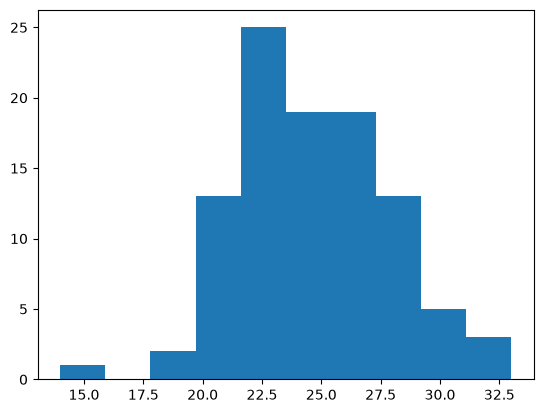

In [9]:
plt.hist(amostra)

3. Use a função `np.linspace` para reproduzir os passos anteriores para diferentes valores de $p$, compare o tempo de execução dos dois métodos. Para cada valor de $p$, execute cada método 100 vezes e calcule a média dos tempos. Utilize `time.time()` para medir o tempo de execução de cada método.

### Variando P

In [15]:
X = []
tempo1p = []
ps = np.linspace(start = 0, stop= 0.99, num = 50)
for p in tqdm(ps):
    comeco = time.time()
    for i in range(N):
        U = np.random.uniform(size= n)
        X.append(np.sum(U < p))
    tempo1p.append(time.time() - comeco)

100%|██████████| 50/50 [00:00<00:00, 645.79it/s]


In [16]:
tempo2p = []
for p in tqdm(ps):
    comeco = time.time()
    X2 = []
    for _ in range(N):
        U = np.random.uniform()
        i = 0
        pi = (1-p)**n
        F = pi
        while U > F:
            pi = (n-i) * p * pi/((i+1) * (1-p))
            i += 1
            F += pi
        X2.append(i)
    tempo2p.append(time.time() - comeco)

100%|██████████| 50/50 [00:00<00:00, 249.37it/s]


In [17]:
print(f'Tempo médio para ingênua: {np.mean(tempo1p)}')
print(f'Tempo médio para inversa da F: {np.mean(tempo2p)}')

Tempo médio para ingênua: 0.0015290737152099609
Tempo médio para inversa da F: 0.003965678215026855


4. Apresente os resultados em uma tabela ou gráfico e comente como o tempo de execução dos métodos varia com $p$.

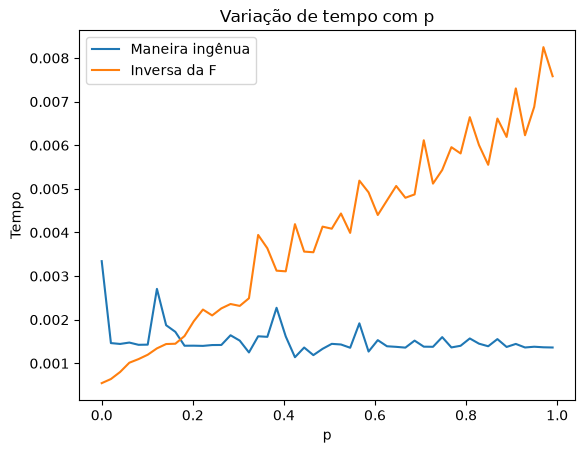

In [18]:
plt.plot(ps, tempo1p)
plt.plot(ps, tempo2p)
plt.title('Variação de tempo com p')
plt.legend(['Maneira ingênua', 'Inversa da F'])
plt.xlabel('p')
plt.ylabel('Tempo')
plt.show()

### Variando N

In [19]:
p = 0.5
tempo1n = []
ns = np.linspace(start = 10, stop= 1000, num = 500).astype(int)
for n in tqdm(ns):
    comeco = time.time()
    for i in range(N):
        U = np.random.uniform(size= n)
        X.append(np.sum(U < p))
    tempo1n.append(time.time() - comeco)

100%|██████████| 500/500 [00:01<00:00, 392.30it/s]


In [20]:
tempo2n = []
for n in tqdm(ns):
    comeco = time.time()
    X2 = []
    for _ in range(N):
        U = np.random.uniform()
        i = 0
        pi = (1-p)**n
        F = pi
        while U > F:
            pi = (n-i) * p * pi/((i+1) * (1-p))
            i += 1
            F += pi
        X2.append(i)
    tempo2n.append(time.time() - comeco)

100%|██████████| 500/500 [02:20<00:00,  3.55it/s]


In [21]:
print(f'Tempo médio para ingênua: {np.mean(tempo1n)}')
print(f'Tempo médio para inversa da F: {np.mean(tempo2n)}')

Tempo médio para ingênua: 0.0025049853324890137
Tempo médio para inversa da F: 0.2785841193199158


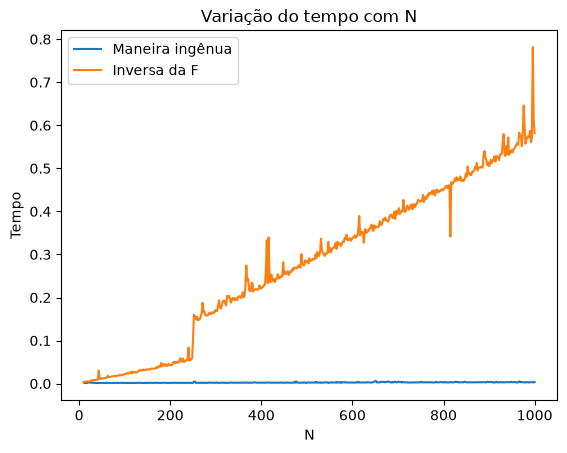

In [22]:
plt.plot(ns, tempo1n)
plt.plot(ns, tempo2n)
plt.xlabel('N')
plt.ylabel('Tempo')
plt.title('Variação do tempo com N')
plt.legend(['Maneira ingênua', 'Inversa da F'])
plt.show()